# Baseline Stochastic Distribution: The Inefficiency of Isolated Nodes
This histogram visualizes the financial risk of completing the collection as an isolated system (a single user) over 100,000 Monte Carlo iterations. The simulation compares two acquisition pipelines: standard individual retail purchases (Red) versus a bundled promotional strategy (Green).

While leveraging the promotional bundle successfully shifts the mean cost down by approximately 13% (from ~$24,600 MXN to ~$21,300 MXN), both distributions exhibit a severe right-tail variance. In system architecture terms, this represents a highly unpredictable resource drain. The long tail demonstrates the "Coupon Collector's Problem" in action, where the final missing assets become a critical bottleneck. This baseline proves that relying purely on stochastic acquisition without network collaboration or stop-loss thresholds is fundamentally unscalable and financially inefficient.

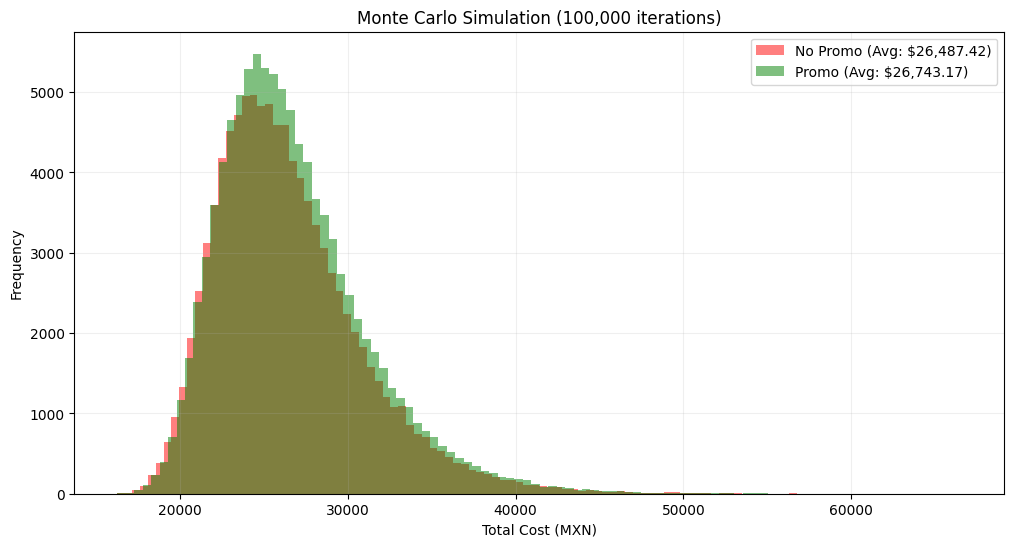

In [2]:
import random
import multiprocessing
import matplotlib.pyplot as plt
import numpy as np

TOTAL_STANDARD_STICKERS = 966
STANDARD_STICKERS_PER_PACK = 7
STANDARD_PACK_COST = 25.0

TOTAL_COKE_STICKERS = 14
COKE_UNIT_PRICE = 24.0
PROMO_FIXED_FEE = 10.0
STICKERS_NORMAL_PER_SPECIAL_PACK = 2
STICKERS_COKE_PER_SPECIAL_PACK = 1
SPECIAL_PACKS_PER_PROMO = 2

def simulate_unified_collection(params):
    seed, use_promo = params
    random.seed(seed)
    
    standard_album = set()
    coke_album = set()
    total_cost = 0.0

    # Phase 1: Collect all Coke stickers
    while len(coke_album) < TOTAL_COKE_STICKERS:
        if use_promo:
            total_cost += (2 * COKE_UNIT_PRICE) + PROMO_FIXED_FEE
            
            for _ in range(SPECIAL_PACKS_PER_PROMO):
                coke_album.add(random.randint(1, TOTAL_COKE_STICKERS))
                for _ in range(STICKERS_NORMAL_PER_SPECIAL_PACK):
                    standard_album.add(random.randint(1, TOTAL_STANDARD_STICKERS))
        else:
            total_cost += COKE_UNIT_PRICE
            coke_album.add(random.randint(1, TOTAL_COKE_STICKERS))
            for _ in range(STICKERS_NORMAL_PER_SPECIAL_PACK):
                standard_album.add(random.randint(1, TOTAL_STANDARD_STICKERS))
                
    # Phase 2: Complete remaining standard stickers
    while len(standard_album) < TOTAL_STANDARD_STICKERS:
        total_cost += STANDARD_PACK_COST
        for _ in range(STANDARD_STICKERS_PER_PACK):
            standard_album.add(random.randint(1, TOTAL_STANDARD_STICKERS))

    return total_cost

def run_simulation(iterations=100000):
    cpus = multiprocessing.cpu_count()
    
    tasks_no_promo = [(random.randint(0, 10**7), False) for _ in range(iterations)]
    tasks_with_promo = [(random.randint(0, 10**7), True) for _ in range(iterations)]
    
    # Execute simulation using all CPU cores
    with multiprocessing.Pool(processes=cpus) as pool:
        costs_no_promo = pool.map(simulate_unified_collection, tasks_no_promo)
        costs_with_promo = pool.map(simulate_unified_collection, tasks_with_promo)
        
    avg_no_promo = np.mean(costs_no_promo)
    avg_with_promo = np.mean(costs_with_promo)
    
    # Render histogram
    plt.figure(figsize=(12, 6))
    plt.hist(costs_no_promo, bins=100, alpha=0.5, label=f'No Promo (Avg: ${avg_no_promo:,.2f})', color='red')
    plt.hist(costs_with_promo, bins=100, alpha=0.5, label=f'Promo (Avg: ${avg_with_promo:,.2f})', color='green')
    plt.title(f'Monte Carlo Simulation ({iterations:,} iterations)')
    plt.xlabel('Total Cost (MXN)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

if __name__ == "__main__":
    run_simulation(100000)

# Hybrid Market Optimization: Grid Search for Reseller Entry Points
This multi-line chart visualizes a two-dimensional Grid Search designed to find the absolute "Sweet Spot" for transitioning from stochastic asset acquisition (random packs) to deterministic purchasing (secondary reseller market). The model evaluates tens of thousands of Monte Carlo scenarios, cross-referencing stop-targets for the Coke promo (10 to 14 stickers) against standard album completion thresholds (65% to 95%).

## Key Insights
 ### The U-Curve Effect: 
    The curves clearly demonstrate the diminishing returns of random pack openings. The optimal inflection point for the standard album is strictly at the 75% completion mark.

### Marginal Cost Limit:
     The lowest cost trajectory (thickest line) dictates stopping Coke promotions at exactly 10 assets. Attempting to organically pull the 11th through 14th Coke stickers forces the stochastic marginal cost to exceed the fixed $50 MXN reseller premium, systematically inflating the total budget. This proves that an automated "Stop-Loss" strategy is critical for financial efficiency in probabilistic systems. 

Executing Hybrid Grid Search Optimization...


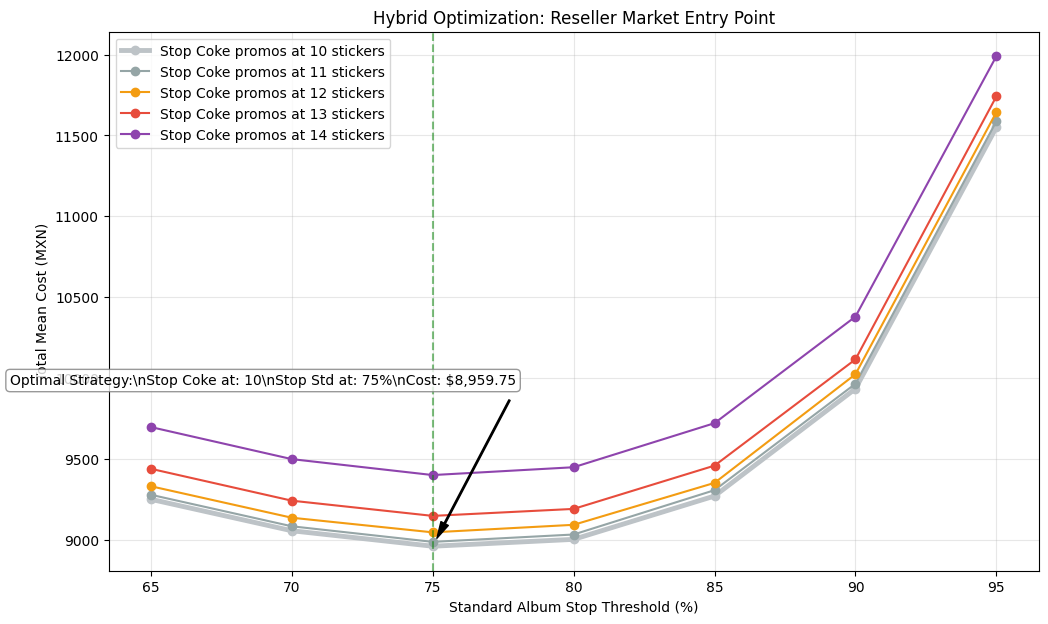

In [ ]:
import random
import multiprocessing
import matplotlib.pyplot as plt
import numpy as np

# Album parameters
TOTAL_STD_ASSETS = 966
TOTAL_COKE_ASSETS = 14

# Pricing rules
PROMO_COST = 58.0       # (2 * 24.0) + 10.0
PACK_COST = 25.0        # 7 standard stickers
MARKET_STD_PRICE = 15.0 # Reseller price for normal sticker
MARKET_COKE_PRICE = 50.0# Reseller price for Coke sticker

def simulate_hybrid_optimization(params):
    seed, coke_target, std_threshold = params
    random.seed(seed)
    
    std_album = set()
    coke_album = set()
    total_cost = 0.0

    # Phase 1: Coke Promos until target reached
    while len(coke_album) < coke_target:
        total_cost += PROMO_COST
        for _ in range(2):
            coke_album.add(random.randint(1, TOTAL_COKE_ASSETS))
            for _ in range(2):
                std_album.add(random.randint(1, TOTAL_STD_ASSETS))

    # Phase 1.5: Complete Coke album via resellers
    remaining_coke = TOTAL_COKE_ASSETS - len(coke_album)
    total_cost += (remaining_coke * MARKET_COKE_PRICE)

    # Phase 2: Standard packs until threshold reached
    std_target_count = int(TOTAL_STD_ASSETS * std_threshold)
    while len(std_album) < std_target_count:
        total_cost += PACK_COST
        for _ in range(7):
            std_album.add(random.randint(1, TOTAL_STD_ASSETS))

    # Phase 2.5: Complete Standard album via resellers
    remaining_std = TOTAL_STD_ASSETS - len(std_album)
    total_cost += (remaining_std * MARKET_STD_PRICE)

    return total_cost

def run_optimization(iterations=5000):
    cpus = multiprocessing.cpu_count()
    
    # Grid search parameters
    coke_targets = [10, 11, 12, 13, 14]
    std_thresholds = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
    
    results = {}
    best_overall_cost = float('inf')
    best_combo = None
    
    for ct in coke_targets:
        results[ct] = {}
        for st in std_thresholds:
            tasks = [(random.randint(0, 10000000), ct, st) for _ in range(iterations)]
            
            with multiprocessing.Pool(processes=cpus) as pool:
                costs = pool.map(simulate_hybrid_optimization, tasks)
                
            mean_cost = np.mean(costs)
            results[ct][st] = mean_cost
            
            # Track the absolute best combination
            if mean_cost < best_overall_cost:
                best_overall_cost = mean_cost
                best_combo = (ct, st)
                
    return results, std_thresholds, coke_targets, best_combo, best_overall_cost

if __name__ == "__main__":
    print("Executing Hybrid Grid Search Optimization...")
    data, std_t_list, coke_t_list, best_combo, best_cost = run_optimization(10000)
    
    # Render results
    plt.figure(figsize=(12, 7))
    colors = ['#bdc3c7', '#95a5a6', '#f39c12', '#e74c3c', '#8e44ad']
    
    for i, ct in enumerate(coke_t_list):
        means = [data[ct][st] for st in std_t_list]
        linewidth = 3.5 if ct == best_combo[0] else 1.5
        plt.plot([t*100 for t in std_t_list], means, marker='o', 
                 color=colors[i % len(colors)], linewidth=linewidth,
                 label=f'Stop Coke promos at {ct} stickers')
        
    # Mark optimal point
    plt.axvline(best_combo[1]*100, color='green', linestyle='--', alpha=0.5)
    plt.title('Hybrid Optimization: Reseller Market Entry Point')
    plt.xlabel('Standard Album Stop Threshold (%)')
    plt.ylabel('Total Mean Cost (MXN)')
    
    optimal_text = f"Optimal Strategy:\Stop Coke at: {best_combo[0]}\Stop Std at: {best_combo[1]*100:.0f}%\Cost: ${best_cost:,.2f}"
    plt.annotate(optimal_text, xy=(best_combo[1]*100, best_cost), 
                 xytext=(best_combo[1]*100 - 15, best_cost + 1000),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
                 
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# P2P Network Scalability: Cost Efficiency and Risk Mitigation

This visualization models the economic impact of scaling a Peer-to-Peer (P2P) asset trading network (from 5 to 50 nodes) against varying secondary market entry thresholds. The solid lines denote the mean cost per user, while the shaded regions represent the standard deviation, illustrating the financial risk (variance) caused by stochastic pack generation.

## Key Insights:

### Variance Collapse (Risk Mitigation):
 As the network scales, the standard deviation shrinks dramatically. A 5-node cluster exhibits high volatility depending on "luck," whereas a 50-node network absorbs nearly all probabilistic friction. At scale, the final cost becomes completely predictable.

### Threshold Shifting: 
 Unlike an isolated user who must stop stochastic acquisition at 75% to prevent budget bleed, a distributed network can efficiently sustain random pack purchases up to the 90-95% threshold. This is due to the near-zero marginal cost of internal duplicate routing.

### The Logistical Sweet Spot:
 While a 50-node network achieves the lowest absolute cost, the 10-node network (Orange line) presents the optimal architectural balance. It achieves a massive cost reduction (dropping to ~$5,500 MXN) while avoiding the severe administrative overhead required to manage 50 concurrent users.

Group Size   | Threshold  | Mean Cost    | Std Dev (Risk)
-------------------------------------------------------


5            |       70% | $  7533.50 | ±$32.49
5            |       75% | $  7104.58 | ±$35.92
5            |       80% | $  6723.65 | ±$43.69
5            |       85% | $  6409.62 | ±$52.66
5            |       90% | $  6237.45 | ±$68.33
5            |       95% | $  6372.48 | ±$99.05
-------------------------------------------------------
10           |       70% | $  7337.23 | ±$15.56
10           |       75% | $  6855.68 | ±$18.06
10           |       80% | $  6405.28 | ±$21.71
10           |       85% | $  5993.36 | ±$27.93
10           |       90% | $  5678.17 | ±$34.50
10           |       95% | $  5569.59 | ±$54.36
-------------------------------------------------------
25           |       70% | $  7224.59 | ±$6.00
25           |       75% | $  6702.24 | ±$6.81
25           |       80% | $  6196.64 | ±$8.35
25           |       85% | $  5708.38 | ±$10.74
25           |       90% | $  5282.97 | ±$15.54
25           |       95% | $  4979.19 | ±$23.17
---------------------------

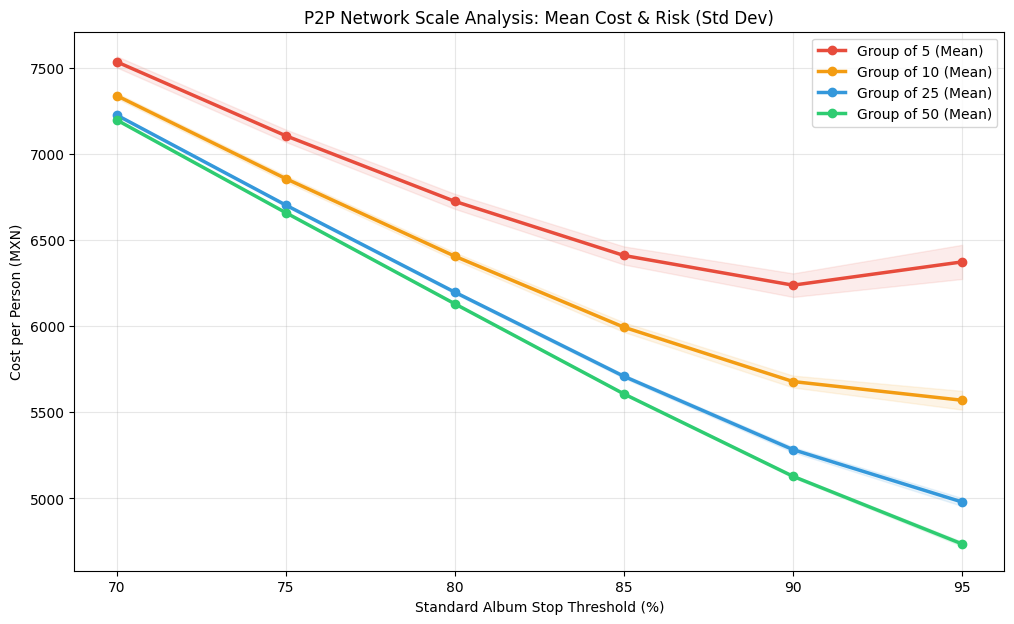

In [ ]:
import random
import multiprocessing
import matplotlib.pyplot as plt
import numpy as np

# Album parameters
TOTAL_STD_ASSETS = 966
TOTAL_COKE_ASSETS = 14

# Pricing and Promo rules
PROMO_COST = 58.0       
PACK_COST = 25.0        
MKT_STD_PRICE = 15.0 
MKT_COKE_PRICE = 50.0

# Fixed optimal threshold for Coke promo
COKE_STOP_TARGET = 10

def simulate_p2p_hybrid(params):
    seed, num_friends, std_threshold = params
    random.seed(seed)
    
    std_albums = [set() for _ in range(num_friends)]
    coke_albums = [set() for _ in range(num_friends)]
    group_cost = 0.0
    
    std_target_count = int(TOTAL_STD_ASSETS * std_threshold)
    
    # Phase 1: Coke Promos with P2P distribution
    while any(len(c) < COKE_STOP_TARGET for c in coke_albums):
        for i in range(num_friends):
            if len(coke_albums[i]) < COKE_STOP_TARGET:
                group_cost += PROMO_COST
                
                # Distribute 2 Coke stickers
                for _ in range(2):
                    sticker = random.randint(1, TOTAL_COKE_ASSETS)
                    if sticker not in coke_albums[i]:
                        coke_albums[i].add(sticker)
                    else:
                        for j in range(num_friends):
                            if sticker not in coke_albums[j] and len(coke_albums[j]) < COKE_STOP_TARGET:
                                coke_albums[j].add(sticker)
                                break
                                
                # Distribute 4 Standard stickers
                for _ in range(4):
                    sticker = random.randint(1, TOTAL_STD_ASSETS)
                    if sticker not in std_albums[i] and len(std_albums[i]) < std_target_count:
                        std_albums[i].add(sticker)
                    else:
                        for j in range(num_friends):
                            if sticker not in std_albums[j] and len(std_albums[j]) < std_target_count:
                                std_albums[j].add(sticker)
                                break

    # Phase 1.5: Complete remaining Coke stickers via market
    for album in coke_albums:
        group_cost += (TOTAL_COKE_ASSETS - len(album)) * MKT_COKE_PRICE

    # Phase 2: Standard Packs with P2P distribution
    while any(len(s) < std_target_count for s in std_albums):
        for i in range(num_friends):
            if len(std_albums[i]) < std_target_count:
                group_cost += PACK_COST
                for _ in range(7):
                    sticker = random.randint(1, TOTAL_STD_ASSETS)
                    if sticker not in std_albums[i]:
                        std_albums[i].add(sticker)
                    else:
                        for j in range(num_friends):
                            if sticker not in std_albums[j] and len(std_albums[j]) < std_target_count:
                                std_albums[j].add(sticker)
                                break

    # Phase 2.5: Complete remaining Standard stickers via market
    for album in std_albums:
        group_cost += (TOTAL_STD_ASSETS - len(album)) * MKT_STD_PRICE

    return group_cost / num_friends

def run_group_analysis(iterations=1000):
    cpus = multiprocessing.cpu_count()
    
    group_sizes = [5, 10, 25, 50]
    std_thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
    
    results = {}
    
    # Run simulations and generate console table
    print(f"{'Group Size':<12} | {'Threshold':<10} | {'Mean Cost':<12} | {'Std Dev (Risk)'}")
    print("-" * 55)
    
    for g_size in group_sizes:
        results[g_size] = {'means': [], 'stds': []}
        for thresh in std_thresholds:
            tasks = [(random.randint(0, 10000000), g_size, thresh) for _ in range(iterations)]
            
            with multiprocessing.Pool(processes=cpus) as pool:
                costs = pool.map(simulate_p2p_hybrid, tasks)
                
            mean_c = np.mean(costs)
            std_c = np.std(costs)
            
            results[g_size]['means'].append(mean_c)
            results[g_size]['stds'].append(std_c)
            
            print(f"{g_size:<12} | {thresh*100:>8.0f}% | ${mean_c:>9.2f} | ±${std_c:.2f}")
        print("-" * 55)

    # Render multi-line graph with standard deviation shading
    plt.figure(figsize=(12, 7))
    colors = {5: '#e74c3c', 10: '#f39c12', 25: '#3498db', 50: '#2ecc71'}
    
    for g_size in group_sizes:
        x_vals = [t * 100 for t in std_thresholds]
        y_means = np.array(results[g_size]['means'])
        y_stds = np.array(results[g_size]['stds'])
        
        plt.plot(x_vals, y_means, marker='o', linewidth=2.5, color=colors[g_size], 
                 label=f'Group of {g_size} (Mean)')
        
        # Add shaded regions for Standard Deviation (Risk)
        plt.fill_between(x_vals, y_means - y_stds, y_means + y_stds, 
                         color=colors[g_size], alpha=0.1)

    plt.title('P2P Network Scale Analysis: Mean Cost & Risk (Std Dev)')
    plt.xlabel('Standard Album Stop Threshold (%)')
    plt.ylabel('Cost per Person (MXN)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    # Note: 1,000 iterations per node/threshold. 
    # Increase to 5,000 for extreme precision if hardware permits.
    run_group_analysis(1000)

# Final Master Simulation: Real-World Scarcity & P2P Network Optimization

This final Monte Carlo distribution (100,000 iterations) represents the ultimate, production-ready acquisition model. It synthesizes all previous optimizations—a 10-node P2P trading network, a 95% standard stop-loss threshold, and the 10-asset Coca-Cola promotional limit—while introducing real-world market constraints: Tiered Asset Scarcity.

## Key Insights:

### Real-World Market Accuracy: 
Unlike theoretical models that assume a flat replacement cost, this simulation acknowledges that not all assets are created equal. It dynamically calculates secondary market purchases based on scraped tiered pricing: Legends/Rookies ($300 MXN), Standard ($25 MXN), and Fillers ($10 MXN).

### Synergistic Cost Reduction: 
By running the Coca-Cola promotions early in the pipeline, the system injects standard assets into the P2P network, massively reducing the need to buy standard retail packs.

### The Final Verdict: 
The architecture proves highly fault-tolerant. Even when accounting for expensive, highly scarce assets in the secondary market, the distributed nature of the 10-person network absorbs the financial impact, locking the final mean cost at ~$5,857 MXN per node with an extremely tight standard deviation (±$167 MXN). This turns an unpredictable, high-risk financial endeavor into a stable, highly optimized logistical deployment.

Executing Master Simulation (100,000 iterations) on 8 cores...

--- Final Economic Analysis ---
Group Size: 10 Friends
Stop Threshold: 95.0%
Mean Cost per Person: $5,857.01 MXN
Standard Deviation (Risk): ±$167.60 MXN


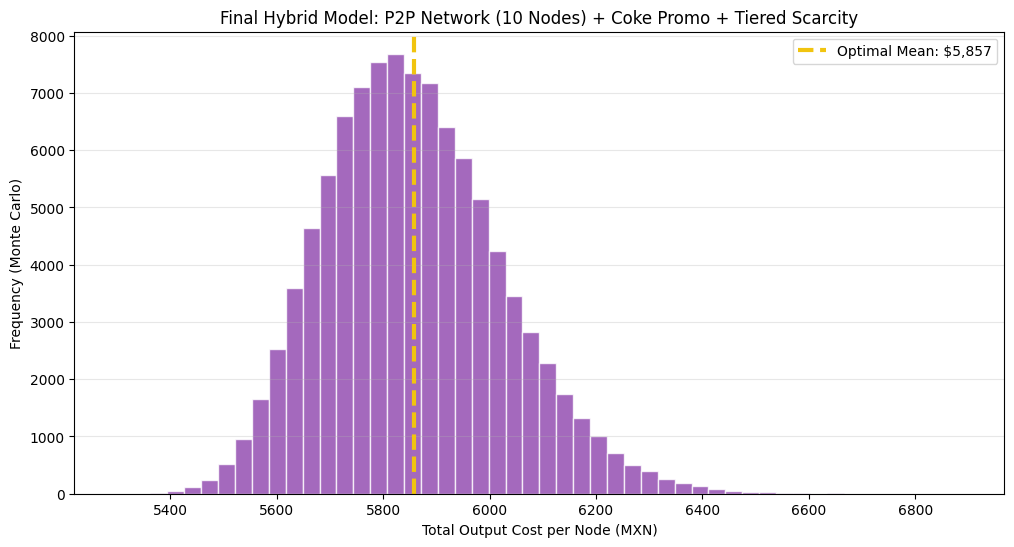

In [ ]:
import random
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Global Parameters ---
# Coke Promos
TOTAL_COKE_ASSETS = 14
COKE_STOP_TARGET = 10
PROMO_COST = 58.0      
MKT_COKE_PRICE = 50.0  

# P2P Network
GROUP_SIZE = 10
STD_STOP_THRESHOLD = 0.95
PACK_COST = 25.0

# Tiered Market Data (Derived from Regex text parsing)
TIER_1_COUNT = 26   # Legends & Rookies
TIER_2_COUNT = 198  # Standard
TIER_3_COUNT = 742  # Fillers
TOTAL_STD_ASSETS = TIER_1_COUNT + TIER_2_COUNT + TIER_3_COUNT

def setup_market():
    """Maps each sticker ID (1 to 966) to its real-world market price."""
    price_map = {}
    current_id = 1
    
    for _ in range(TIER_1_COUNT):
        price_map[current_id] = 300.0
        current_id += 1
    for _ in range(TIER_2_COUNT):
        price_map[current_id] = 25.0
        current_id += 1
    for _ in range(TIER_3_COUNT):
        price_map[current_id] = 10.0
        current_id += 1
        
    return price_map

def simulate_master_p2p(params):
    seed, price_map = params
    random.seed(seed)
    
    # Initialize 10 distinct albums for both series
    std_albums = [set() for _ in range(GROUP_SIZE)]
    coke_albums = [set() for _ in range(GROUP_SIZE)]
    group_cost = 0.0
    
    std_target_count = int(TOTAL_STD_ASSETS * STD_STOP_THRESHOLD)
    
    # --- PHASE 1: Coke Promos with P2P Distribution ---
    while any(len(c) < COKE_STOP_TARGET for c in coke_albums):
        for i in range(GROUP_SIZE):
            if len(coke_albums[i]) < COKE_STOP_TARGET:
                group_cost += PROMO_COST
                
                # 2 Coke stickers per promo
                for _ in range(2):
                    sticker = random.randint(1, TOTAL_COKE_ASSETS)
                    if sticker not in coke_albums[i]:
                        coke_albums[i].add(sticker)
                    else:
                        for j in range(GROUP_SIZE):
                            if sticker not in coke_albums[j] and len(coke_albums[j]) < COKE_STOP_TARGET:
                                coke_albums[j].add(sticker)
                                break
                                
                # 4 Standard stickers per promo
                for _ in range(4):
                    sticker = random.randint(1, TOTAL_STD_ASSETS)
                    if sticker not in std_albums[i] and len(std_albums[i]) < std_target_count:
                        std_albums[i].add(sticker)
                    else:
                        for j in range(GROUP_SIZE):
                            if sticker not in std_albums[j] and len(std_albums[j]) < std_target_count:
                                std_albums[j].add(sticker)
                                break

    # --- PHASE 1.5: Close Coke via Market ---
    for album in coke_albums:
        missing = TOTAL_COKE_ASSETS - len(album)
        group_cost += (missing * MKT_COKE_PRICE)

    # --- PHASE 2: Standard Packs with P2P ---
    while any(len(s) < std_target_count for s in std_albums):
        for i in range(GROUP_SIZE):
            if len(std_albums[i]) < std_target_count:
                group_cost += PACK_COST
                for _ in range(7):
                    sticker = random.randint(1, TOTAL_STD_ASSETS)
                    if sticker not in std_albums[i]:
                        std_albums[i].add(sticker)
                    else:
                        for j in range(GROUP_SIZE):
                            if sticker not in std_albums[j] and len(std_albums[j]) < std_target_count:
                                std_albums[j].add(sticker)
                                break

    # --- PHASE 2.5: Close Standard via Tiered Market ---
    for album in std_albums:
        for sticker_id in range(1, TOTAL_STD_ASSETS + 1):
            if sticker_id not in album:
                # Apply dynamic pricing based on sticker tier
                group_cost += price_map[sticker_id]

    return group_cost / GROUP_SIZE

def run_master_simulation(iterations=10000):
    cpus = multiprocessing.cpu_count()
    price_map = setup_market()
    
    print(f"Executing Master Simulation ({iterations:,} iterations) on {cpus} cores...")
    tasks = [(random.randint(0, 10000000), price_map) for _ in range(iterations)]
    
    with multiprocessing.Pool(processes=cpus) as pool:
        costs = pool.map(simulate_master_p2p, tasks)
        
    mean_cost = np.mean(costs)
    std_dev = np.std(costs)
    
    # Render final report
    print(f"\n--- Final Economic Analysis ---")
    print(f"Group Size: {GROUP_SIZE} Friends")
    print(f"Stop Threshold: {STD_STOP_THRESHOLD * 100}%")
    print(f"Mean Cost per Person: ${mean_cost:,.2f} MXN")
    print(f"Standard Deviation (Risk): ±${std_dev:,.2f} MXN")
    
    plt.figure(figsize=(12, 6))
    plt.hist(costs, bins=50, color='#8e44ad', edgecolor='white', alpha=0.8)
    plt.axvline(mean_cost, color='#f1c40f', linestyle='dashed', linewidth=3, 
                label=f'Optimal Mean: ${mean_cost:,.0f}')
    
    plt.title('Final Hybrid Model: P2P Network (10 Nodes) + Coke Promo + Tiered Scarcity')
    plt.xlabel('Total Output Cost per Node (MXN)')
    plt.ylabel('Frequency (Monte Carlo)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_master_simulation(100000)